# Step 1: Exploratory Data Analysis (EDA) & Preprocessing
**Role: Person A (Data & ML Engineer)**

Notebook ini berisi langkah-langkah **Step 1** dalam proyek ABSA + Review Quality Filter:
1. **Inisialisasi Apache Spark (PySpark)** dengan optimasi memori untuk pengolahan dataset besar.
2. **Load Dataset** Amazon Electronics (1.73 GB, ~3.09 juta baris ulasan).
3. **Visualisasi Data Awal** sebelum diproses.
4. **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset (distribusi rating, missing values, ulasan, verified purchase, dll.).
5. **Data Preprocessing & Cleaning** (penanganan data kosong, pembersihan teks dari HTML tag, lowercase).
6. **Feature Engineering Awal** (pembuatan variabel sentimen dan rasio review bermanfaat).
7. **Visualisasi Data Setelah Preprocessing**.
8. **Stratified Sampling (40%)** untuk membatasi ukuran dataset secara proporsional demi efisiensi step berikutnya.
9. **Visualisasi Data Hasil Akhir** sebelum disimpan.
10. **Export Data** ke format Parquet (`data/processed/reviews_clean.parquet`).

---
## 1. Import Libraries & Setup Spark Session

In [13]:
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Append parent directory to sys.path to allow config import
sys.path.append(os.path.abspath('..'))
import config

# Setup PySpark Session with Memory Optimizations
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower, regexp_replace, when, length, split, size

spark = SparkSession.builder \
    .appName("AmazonElectronicsEDA") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.driver.extraJavaOptions", "-Djava.security.manager=allow") \
    .getOrCreate()

print("Spark Session initialized successfully!")
print(f"Spark Version: {spark.version}")

Spark Session initialized successfully!
Spark Version: 4.1.1


---
## 2. Load Dataset Amazon Electronics

In [14]:
print(f"Loading raw dataset from: {config.RAW_TSV_PATH}")

# Load TSV dataset (using tab-separated value format)
df = spark.read.csv(
    config.RAW_TSV_PATH, 
    sep="\t", 
    header=True, 
    inferSchema=True
)

# Get total rows and schema
total_rows = df.count()
print(f"Total baris dalam dataset mentah: {total_rows:,}")
df.printSchema()

# Tampilkan 1000 baris pertama data mentah seperti Data Wrangler
df.limit(1000).toPandas()

Loading raw dataset from: d:\big data\final project\dataset\amazon_reviews_us_Electronics_v1_00.tsv\amazon_reviews_us_Electronics_v1_00.tsv
Total baris dalam dataset mentah: 3,093,869
root
 |-- marketplace: string (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: integer (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)



,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,41409413,R2MTG1GCZLR2DK,B00428R89M,112201306,yoomall 5M Antenna WIFI RP-SMA Female to Male ...,Electronics,5,0,0,N,Y,Five Stars,As described.,2015-08-31
1,US,49668221,R2HBOEM8LE9928,B000068O48,734576678,"Hosa GPM-103 3.5mm TRS to 1/4"" TRS Adaptor",Electronics,5,0,0,N,Y,It works as advertising.,It works as advertising.,2015-08-31
2,US,12338275,R1P4RW1R9FDPEE,B000GGKOG8,614448099,Channel Master Titan 2 Antenna Preamplifier,Electronics,5,1,1,N,Y,Five Stars,Works pissa,2015-08-31
3,US,38487968,R1EBPM82ENI67M,B000NU4OTA,72265257,LIMTECH Wall charger + USB Hotsync & Charging ...,Electronics,1,0,0,N,Y,One Star,Did not work at all.,2015-08-31
4,US,23732619,R372S58V6D11AT,B00JOQIO6S,308169188,Skullcandy Air Raid Portable Bluetooth Speaker,Electronics,5,1,1,N,Y,Overall pleased with the item,Works well. Bass is somewhat lacking but is pr...,2015-08-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,US,32507707,R1ZMJ830PSKBPL,B00ZMISD2C,562970498,Superior Full Motion TV Bracket Wall Mount Fit...,Electronics,5,0,0,N,Y,Great wall Mount for the price easy to assembl...,Great wall Mount for the price easy to assembl...,2015-08-31
996,US,51529929,RAAZD2N6YW6TT,B00PJKZFJC,60420947,Sony MDR-ZX100 Stereo Wired Headphones Over-th...,Electronics,4,0,0,N,Y,these are really good headphones. I recommend ...,"For the price, these are really good headphone...",2015-08-31
997,US,47475027,R268WDA1TRKRJB,B00LVWSVM0,120051589,1.2m NEW Replacement Audio upgrade Cable For S...,Electronics,1,2,3,N,Y,Inserted the cable into the HD7 DJ and turned ...,Inserted the cable into the HD7 DJ and turned ...,2015-08-31
998,US,52246189,R29IBVF94FREAY,B00PAJBCOO,998408393,Kootek Universal Worldwide International Trave...,Electronics,2,0,0,N,Y,A little bulkier than I would have liked. Not ...,A little bulkier than I would have liked. Not ...,2015-08-31


---
## 3. Exploratory Data Analysis (EDA)

Sebelum melakukan pemrosesan, kita lakukan EDA untuk melihat kualitas data dan distribusinya.

### 3.1. Cek Missing Values (Data Kosong)

In [15]:
# Mengecek null values pada kolom-kolom krusial
print("Mengecek missing values pada kolom krusial:")
cols_to_check = ["review_body", "star_rating", "helpful_votes", "total_votes"]

for c in cols_to_check:
    null_count = df.filter(col(c).isNull()).count()
    print(f"- Kolom '{c}': {null_count:,} baris kosong ({null_count/total_rows*100:.4f}%)")

Mengecek missing values pada kolom krusial:
- Kolom 'review_body': 197 baris kosong (0.0064%)
- Kolom 'star_rating': 8 baris kosong (0.0003%)
- Kolom 'helpful_votes': 8 baris kosong (0.0003%)
- Kolom 'total_votes': 8 baris kosong (0.0003%)


### 3.2. Distribusi `star_rating` (Ground Truth Sentimen)

   star_rating    count  percentage
0          NaN        8    0.000259
1          1.0   358119   11.575118
2          2.0   179180    5.791454
3          3.0   238587    7.711606
4          4.0   536819   17.351058
5          5.0  1781156   57.570505


C:\Users\pearl\AppData\Local\Temp\ipykernel_26580\1165736059.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating_dist, x="star_rating", y="count", palette="Blues_r")


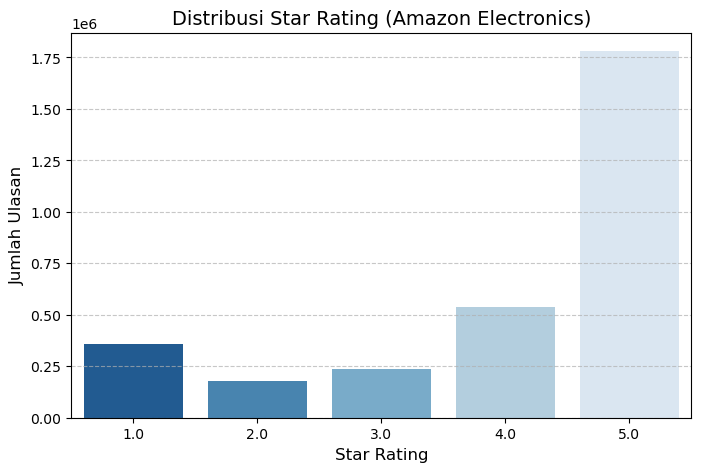

In [16]:
# Agregasi distribusi rating
rating_dist = df.groupBy("star_rating").count().orderBy("star_rating").toPandas()
rating_dist["percentage"] = (rating_dist["count"] / total_rows) * 100
print(rating_dist)

# Visualisasi Distribusi Rating
plt.figure(figsize=(8, 5))
sns.barplot(data=rating_dist, x="star_rating", y="count", palette="Blues_r")
plt.title("Distribusi Star Rating (Amazon Electronics)", fontsize=14)
plt.xlabel("Star Rating", fontsize=12)
plt.ylabel("Jumlah Ulasan", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3.3. Analisis Panjang Teks Ulasan (`review_body`)

        char_length    word_count
count  10000.000000  10000.000000
mean     224.303800     41.236900
std      502.059377     90.135095
min        1.000000      1.000000
25%       34.000000      6.000000
50%       90.000000     16.000000
75%      229.000000     43.000000
max    14572.000000   2596.000000


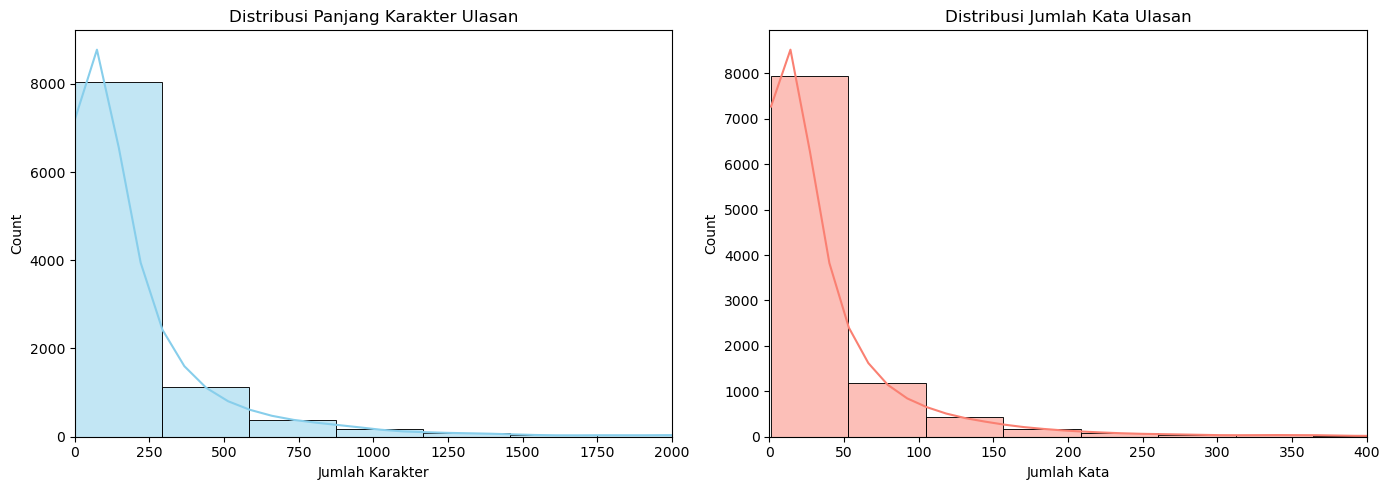

In [17]:
# Menghitung panjang karakter ulasan
df_len = df.filter(col("review_body").isNotNull()) \
           .withColumn("char_length", length(col("review_body"))) \
           .withColumn("word_count", size(split(col("review_body"), "\\s+")))

# Ambil sampel kecil (10.000 baris) untuk statistik visualisasi cepat dengan Pandas
sample_len = df_len.select("char_length", "word_count").sample(False, 0.01, seed=42).limit(10000).toPandas()
print(sample_len.describe())

# Plot distribusi panjang ulasan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(sample_len["char_length"], bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribusi Panjang Karakter Ulasan", fontsize=12)
axes[0].set_xlabel("Jumlah Karakter")
axes[0].set_xlim(0, 2000)  # Batasi agar visualisasi tidak terlalu miring

sns.histplot(sample_len["word_count"], bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribusi Jumlah Kata Ulasan", fontsize=12)
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_xlim(0, 400)

plt.tight_layout()
plt.show()

### 3.4. Rasio verified_purchase dan vine
Mengetahui apakah ulasan ditulis oleh pembeli terverifikasi atau dari program berbayar Vine.

In [18]:
# Verified Purchase Distribution
verified_dist = df.groupBy("verified_purchase").count().toPandas()
verified_dist["percentage"] = (verified_dist["count"] / total_rows) * 100
print("Distribusi Verified Purchase:")
print(verified_dist)

# Vine Program Distribution
vine_dist = df.groupBy("vine").count().toPandas()
vine_dist["percentage"] = (vine_dist["count"] / total_rows) * 100
print("\nDistribusi Program Vine:")
print(vine_dist)

Distribusi Verified Purchase:
  verified_purchase    count  percentage
0              None        8    0.000259
1                 Y  2600222   84.044347
2                 N   493639   15.955394

Distribusi Program Vine:
   vine    count  percentage
0  None        8    0.000259
1     Y    18512    0.598345
2     N  3075349   99.401397


---
## 4. Data Preprocessing & Cleaning

In [19]:
print("Memulai pembersihan data...")

# 1. Drop baris null pada kolom-kolom utama
df_cleaned = df.na.drop(subset=["review_body", "star_rating", "helpful_votes", "total_votes"])

# 2. Membersihkan HTML Tag dan mengubah teks ke lowercase
df_cleaned = df_cleaned.withColumn(
    "review_body", 
    lower(regexp_replace(col("review_body"), "<[^>]+>", ""))
)

print(f"Jumlah baris setelah drop nulls: {df_cleaned.count():,}")

Memulai pembersihan data...
Jumlah baris setelah drop nulls: 3,093,672


---
## 5. Feature Engineering Awal

In [20]:
# 1. Membuat kolom quality_ratio = helpful_votes / (total_votes + 1)
df_cleaned = df_cleaned.withColumn(
    "quality_ratio", 
    col("helpful_votes") / (col("total_votes") + 1)
)

# 2. Membuat kolom sentiment_label dari star_rating
# 0 = Negatif (1-2 bintang), 1 = Netral (3 bintang), 2 = Positif (4-5 bintang)
df_cleaned = df_cleaned.withColumn(
    "sentiment_label",
    when(col("star_rating") <= 2, 0)
    .when(col("star_rating") == 3, 1)
    .otherwise(2)
)

### 🔎 Tampilan Data Setelah Preprocessing
Menampilkan data yang sudah dibersihkan dan memiliki kolom fitur baru (`quality_ratio` & `sentiment_label`).

In [21]:
# Tampilkan 10 baris pertama hasil preprocessing
df_cleaned.select("product_id", "review_body", "star_rating", "sentiment_label", "helpful_votes", "total_votes", "quality_ratio").limit(10).toPandas()

,product_id,review_body,star_rating,sentiment_label,helpful_votes,total_votes,quality_ratio
0,B00428R89M,as described.,5,2,0,0,0.0
1,B000068O48,it works as advertising.,5,2,0,0,0.0
2,B000GGKOG8,works pissa,5,2,1,1,0.5
3,B000NU4OTA,did not work at all.,1,0,0,0,0.0
4,B00JOQIO6S,works well. bass is somewhat lacking but is pr...,5,2,1,1,0.5
5,B008NCD2LG,the quality on these speakers is insanely good...,5,2,1,1,0.5
6,B00007FGUF,wish i could give this product more than five ...,5,2,0,0,0.0
7,B00M9V2RMM,works great,5,2,0,0,0.0
8,B00J3O9DYI,great sound and compact. battery life seems go...,4,2,0,0,0.0
9,B00NS1A0E4,it works well~~~,4,2,0,0,0.0


---
## 6. Stratified Sampling (40%)

In [22]:
print("Memulai stratified sampling...")

# Menentukan fraksi sampling untuk masing-masing kelas sentiment_label
fractions = {0: 0.4, 1: 0.4, 2: 0.4}

df_sampled = df_cleaned.stat.sampleBy("sentiment_label", fractions, seed=42)

total_sampled = df_sampled.count()
print(f"Total baris setelah stratified sampling: {total_sampled:,}")

# Perbandingan distribusi sebelum dan sesudah sampling
dist_before = df_cleaned.groupBy("sentiment_label").count().toPandas()
dist_before["pct_before"] = (dist_before["count"] / df_cleaned.count()) * 100

dist_after = df_sampled.groupBy("sentiment_label").count().toPandas()
dist_after["pct_after"] = (dist_after["count"] / total_sampled) * 100

comparison = dist_before.merge(dist_after, on="sentiment_label", suffixes=('_before', '_after'))
print("\nPerbandingan Distribusi Kelas Sentimen (Sebelum vs Sesudah Sampling):")
print(comparison)

Memulai stratified sampling...
Total baris setelah stratified sampling: 1,239,196

Perbandingan Distribusi Kelas Sentimen (Sebelum vs Sesudah Sampling):
   sentiment_label  count_before  pct_before  count_after  pct_after
0                1        238576    7.711742        95197   7.682158
1                2       2317834   74.921776       929012  74.968931
2                0        537262   17.366482       214987  17.348910


### 🔎 Tampilan Data Hasil Akhir (Sebelum Diekspor)
Mengecek tabel hasil akhir yang siap disimpan ke format Parquet.

In [23]:
# Tampilkan 10 baris pertama data hasil sampling
df_sampled.select("product_id", "review_body", "star_rating", "sentiment_label", "quality_ratio").limit(10).toPandas()

,product_id,review_body,star_rating,sentiment_label,quality_ratio
0,B000NU4OTA,did not work at all.,1,0,0.000000
1,B00M9V2RMM,works great,5,2,0.000000
2,B0035PBHX6,"breaks very easily, and takes a while to load ...",1,0,0.000000
3,B00PLE8QF6,works as advertised.... nothing else to really...,5,2,0.000000
4,B0045EJY90,it does not copy cd-r s to usb as advertised. ...,2,0,0.666667
5,B00ESM3ZHG,great little device if you need to convert mic...,4,2,0.500000
6,B007SP2CO2,excellent sound. good price. ear pads are less...,3,1,0.000000
7,B0111ASH0M,great energy level vi travel charger! very com...,5,2,0.000000
8,B00NTUEDMY,"excellent product, performs as advertised. re...",5,2,0.000000
9,B00RFLXB9Y,"works great in charlotte, nc. received all the...",5,2,0.000000


---
## 7. Export Cleaned Dataset ke format Parquet

In [24]:
print(f"Menyimpan data bersih ke: {config.CLEANED_PARQUET_PATH}")

# Tulis data hasil sample ke Parquet (dengan kompresi Snappy bawaan Spark)
df_sampled.write.mode("overwrite").parquet(config.CLEANED_PARQUET_PATH)

print("Penyimpanan berhasil!")

# Membaca ulang parquet untuk verifikasi
df_check = spark.read.parquet(config.CLEANED_PARQUET_PATH)
print(f"Verifikasi: Parquet berhasil dibaca, total baris = {df_check.count():,}")

Menyimpan data bersih ke: d:\big data\final project\ABSA project\data\processed\reviews_clean.parquet
Penyimpanan berhasil!
Verifikasi: Parquet berhasil dibaca, total baris = 1,239,196


---
## 8. Penutupan Sesi Spark

In [25]:
# Menutup sesi Spark agar memori dilepaskan
spark.stop()
print("Spark Session stopped successfully.")

Spark Session stopped successfully.
